In [1]:
import sys
print('Python version:', sys.version)

Python version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [2]:
!pip install seaborn -q

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report)

np.random.seed(42)
print("All libraries loaded successfully.")

All libraries loaded successfully.


In [4]:
df = pd.read_csv("../data/census.csv", header=None)
df.columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Keep 6 interpretable features + target
df = df[["age", "workclass", "education", "occupation", "sex", "hours-per-week", "income"]]

# Strip whitespace from strings
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

# Handle missing values
df.replace("?", np.nan, inplace=True)
df.dropna(inplace=True)

# Encode target
df["income"] = df["income"].map({"<=50K": 0, ">50K": 1})

print("Dataset shape:", df.shape)
print(df["income"].value_counts())
df.head()

Dataset shape: (30718, 7)
income
0    23068
1     7650
Name: count, dtype: int64


,age,workclass,education,occupation,sex,hours-per-week,income
0,39,State-gov,Bachelors,Adm-clerical,Male,40,0
1,50,Self-emp-not-inc,Bachelors,Exec-managerial,Male,13,0
2,38,Private,HS-grad,Handlers-cleaners,Male,40,0
3,53,Private,11th,Handlers-cleaners,Male,40,0
4,28,Private,Bachelors,Prof-specialty,Female,40,0


In [6]:
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['income'].value_counts(normalize=True).round(3))
print("\nNumerical summary:")
df[['age', 'hours-per-week']].describe()

Dataset shape: (30718, 7)

Class distribution:
income
0    0.751
1    0.249
Name: proportion, dtype: float64

Numerical summary:


,age,hours-per-week
count,30718.000000,30718.000000
mean,38.443584,40.949313
std,13.118227,11.985382
min,17.000000,1.000000
25%,28.000000,40.000000
50%,37.000000,40.000000
75%,47.000000,45.000000
max,90.000000,99.000000


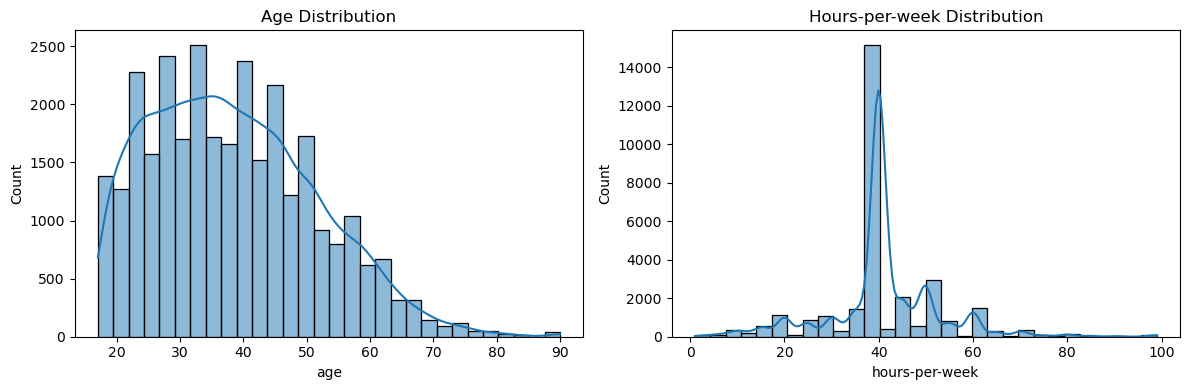

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['age'], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")

sns.histplot(df['hours-per-week'], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Hours-per-week Distribution")

plt.tight_layout()
plt.savefig("EDA_distributions.png", dpi=120)
plt.show()

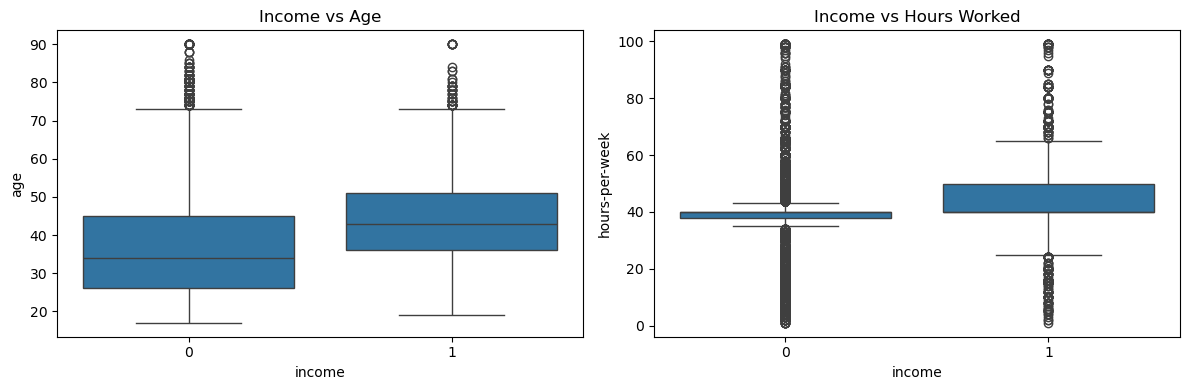

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x='income', y='age', data=df, ax=axes[0])
axes[0].set_title("Income vs Age")

sns.boxplot(x='income', y='hours-per-week', data=df, ax=axes[1])
axes[1].set_title("Income vs Hours Worked")

plt.tight_layout()
plt.savefig("EDA_income_vs_features.png", dpi=120)
plt.show()

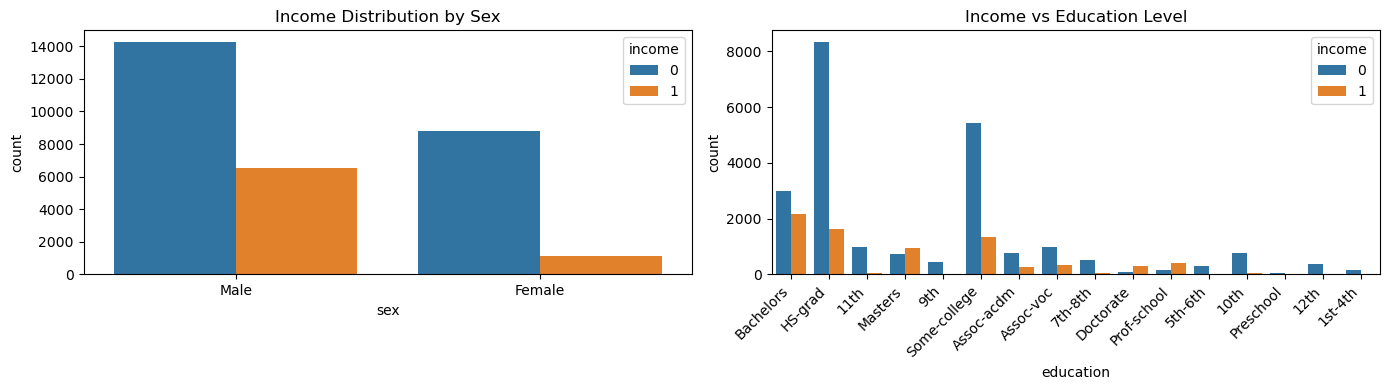

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(x='sex', hue='income', data=df, ax=axes[0])
axes[0].set_title("Income Distribution by Sex")

sns.countplot(x='education', hue='income', data=df, ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_title("Income vs Education Level")

plt.tight_layout()
plt.savefig("EDA_categorical.png", dpi=120)
plt.show()

In [10]:
X = df.drop("income", axis=1)
y = df["income"]

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features   = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:  ", numerical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTrain shape:", X_train.shape, "| Test shape:", X_test.shape)

Categorical features: ['workclass', 'education', 'occupation', 'sex']
Numerical features:   ['age', 'hours-per-week']

Train shape: (24574, 6) | Test shape: (6144, 6)


In [11]:
# Build preprocessor (fit once on clean X_train)
numeric_transformer     = Pipeline([("scaler", StandardScaler())])
categorical_transformer = Pipeline([("onehot", OneHotEncoder(handle_unknown="ignore",
                                                               sparse_output=False))])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer,     numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

# Fit and transform — we work in transformed space for all DP experiments
preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

n_features = X_train_transformed.shape[1]
print(f"Transformed feature space: {n_features} features")

Transformed feature space: 41 features


In [12]:
# ── Baseline: Logistic Regression ──────────────────────────────────────────
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train_transformed, y_train)

y_pred_lr   = lr_baseline.predict(X_test_transformed)
y_prob_lr   = lr_baseline.predict_proba(X_test_transformed)[:, 1]

acc_lr  = accuracy_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_prob_lr)

print("=== Baseline: Logistic Regression (No DP) ===")
print(f"Accuracy : {acc_lr:.4f}")
print(f"F1 Score : {f1_lr:.4f}")
print(f"ROC AUC  : {auc_lr:.4f}")

=== Baseline: Logistic Regression (No DP) ===
Accuracy : 0.8062
F1 Score : 0.5279
ROC AUC  : 0.8314


In [13]:
# ── Baseline: Random Forest ─────────────────────────────────────────────────
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_transformed, y_train)

y_pred_rf   = rf_baseline.predict(X_test_transformed)
y_prob_rf   = rf_baseline.predict_proba(X_test_transformed)[:, 1]

acc_rf  = accuracy_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_prob_rf)

print("=== Baseline: Random Forest (No DP) ===")
print(f"Accuracy : {acc_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"ROC AUC  : {auc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

=== Baseline: Random Forest (No DP) ===
Accuracy : 0.7767
F1 Score : 0.5107
ROC AUC  : 0.7954

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      4614
           1       0.56      0.47      0.51      1530

    accuracy                           0.78      6144
   macro avg       0.70      0.67      0.68      6144
weighted avg       0.77      0.78      0.77      6144



In [14]:
# ── Baseline Comparison Table ────────────────────────────────────────────────
baseline_results = pd.DataFrame({
    "Model": ["Logistic Regression (No DP)", "Random Forest (No DP)"],
    "Accuracy": [acc_lr, acc_rf],
    "F1 Score": [f1_lr, f1_rf],
    "ROC AUC":  [auc_lr, auc_rf]
})
print("Baseline Model Comparison:")
baseline_results

Baseline Model Comparison:


,Model,Accuracy,F1 Score,ROC AUC
0,Logistic Regression (No DP),0.806152,0.527943,0.831444
1,Random Forest (No DP),0.776693,0.510699,0.795411


In [15]:
# Get feature names in transformed space
num_names = numerical_features
cat_names = preprocessor.named_transformers_["cat"]               .named_steps["onehot"].get_feature_names_out(categorical_features).tolist()
all_feature_names = num_names + cat_names

importances = rf_baseline.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature":    all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(f"Total features in transformed space: {len(all_feature_names)}")
print("\nTop 15 most important features:")
feature_importance_df.head(15)

Total features in transformed space: 41

Top 15 most important features:


,feature,importance
0,age,0.425862
1,hours-per-week,0.194422
2,occupation_Exec-managerial,0.031725
3,sex_Female,0.027699
4,occupation_Prof-specialty,0.027004
5,education_Bachelors,0.026959
6,sex_Male,0.023449
7,education_Masters,0.022261
8,education_Prof-school,0.015781
9,education_HS-grad,0.015548


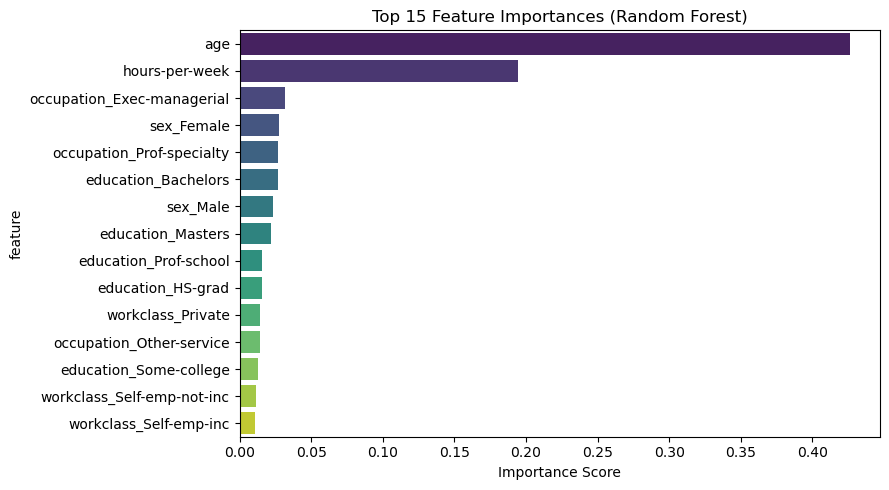

In [16]:
# Plot top 15 feature importances
plt.figure(figsize=(9, 5))
top15 = feature_importance_df.head(15)
sns.barplot(x="importance", y="feature", data=top15, palette="viridis")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importances.png", dpi=120)
plt.show()

In [17]:
# Normalized importances for budget allocation
norm_importances = importances / importances.sum()

print("Importance distribution statistics:")
print(f"  Max importance  : {norm_importances.max():.4f}  (feature: {all_feature_names[np.argmax(norm_importances)]})")
print(f"  Min importance  : {norm_importances.min():.4f}")
print(f"  Ratio max/min   : {norm_importances.max()/norm_importances.min():.1f}x")
print("\nThis large ratio is WHY adaptive DP outperforms fixed DP:")
print("Fixed DP wastes budget on unimportant features — adaptive DP does not.")

Importance distribution statistics:
  Max importance  : 0.4259  (feature: age)
  Min importance  : 0.0001
  Ratio max/min   : 7103.5x

This large ratio is WHY adaptive DP outperforms fixed DP:
Fixed DP wastes budget on unimportant features — adaptive DP does not.


In [18]:
def add_laplace_noise_matrix(X_matrix, epsilons_per_feature, sensitivity=1.0):
    """
    Add Laplace noise to every column of a 2D numpy array.
    
    Parameters:
    - X_matrix           : (n_samples, n_features) numpy array
    - epsilons_per_feature: array of shape (n_features,) — ε for each feature
    - sensitivity        : L1 sensitivity (default 1.0)
    
    Returns:
    - Noisy copy of X_matrix
    """
    X_noisy = X_matrix.copy().astype(float)
    for i, eps in enumerate(epsilons_per_feature):
        eps = max(eps, 1e-9)          # prevent division by zero
        scale = sensitivity / eps
        X_noisy[:, i] += np.random.laplace(0, scale, X_matrix.shape[0])
    return X_noisy


def get_fixed_epsilons(epsilon_total, n_features):
    """Equal budget per feature — the naive/fixed DP approach."""
    return np.full(n_features, epsilon_total / n_features)


def get_adaptive_epsilons(epsilon_total, norm_importances):
    """
    Budget proportional to feature importance.
    Important features → higher ε → less noise → preserved signal.
    Unimportant features → lower ε → more noise → acceptable loss.
    Total budget = epsilon_total (same privacy guarantee as fixed DP).
    """
    n = len(norm_importances)
    return norm_importances * epsilon_total * n   # average ε = epsilon_total


print("Helper functions defined.")
print(f"\nn_features in transformed space: {n_features}")
eps_test = 1.0
fixed_eps   = get_fixed_epsilons(eps_test, n_features)
adap_eps    = get_adaptive_epsilons(eps_test, norm_importances)
print(f"\nAt ε_total=1.0:")
print(f"  Fixed DP  — each feature gets ε = {fixed_eps[0]:.4f}")
print(f"  Adaptive DP — most important feature gets ε = {adap_eps.max():.4f}")
print(f"  Adaptive DP — least important feature gets ε = {adap_eps.min():.6f}")
print(f"  Noise ratio (min/max importance): {adap_eps.max()/adap_eps.min():.0f}x difference in noise scale")

Helper functions defined.

n_features in transformed space: 41

At ε_total=1.0:
  Fixed DP  — each feature gets ε = 0.0244
  Adaptive DP — most important feature gets ε = 17.4603
  Adaptive DP — least important feature gets ε = 0.002458
  Noise ratio (min/max importance): 7104x difference in noise scale


In [19]:
EVAL_EPSILON = 0.1
N_TRIALS     = 30   # average over trials for stable results

fixed_accs, fixed_f1s, fixed_aucs   = [], [], []
adap_accs,  adap_f1s,  adap_aucs    = [], [], []

for trial in range(N_TRIALS):
    # ── Fixed DP ────────────────────────────────────────────────────
    eps_fixed = get_fixed_epsilons(EVAL_EPSILON, n_features)
    X_fixed   = add_laplace_noise_matrix(X_train_transformed, eps_fixed)
    
    lr_fixed  = LogisticRegression(max_iter=1000, random_state=trial).fit(X_fixed, y_train)
    yp_fixed  = lr_fixed.predict(X_test_transformed)
    ypr_fixed = lr_fixed.predict_proba(X_test_transformed)[:, 1]
    
    fixed_accs.append(accuracy_score(y_test, yp_fixed))
    fixed_f1s.append(f1_score(y_test, yp_fixed))
    fixed_aucs.append(roc_auc_score(y_test, ypr_fixed))
    
    # ── Adaptive DP ─────────────────────────────────────────────────
    eps_adap = get_adaptive_epsilons(EVAL_EPSILON, norm_importances)
    X_adap   = add_laplace_noise_matrix(X_train_transformed, eps_adap)
    
    lr_adap  = LogisticRegression(max_iter=1000, random_state=trial).fit(X_adap, y_train)
    yp_adap  = lr_adap.predict(X_test_transformed)
    ypr_adap = lr_adap.predict_proba(X_test_transformed)[:, 1]
    
    adap_accs.append(accuracy_score(y_test, yp_adap))
    adap_f1s.append(f1_score(y_test, yp_adap))
    adap_aucs.append(roc_auc_score(y_test, ypr_adap))

print(f"Results at ε = {EVAL_EPSILON} (averaged over {N_TRIALS} trials)")
print(f"{'Metric':<12} {'No DP':>10} {'Fixed DP':>10} {'Adaptive DP':>12} {'Gap':>8}")
print("-" * 56)
print(f"{'Accuracy':<12} {acc_lr:>10.4f} {np.mean(fixed_accs):>10.4f} {np.mean(adap_accs):>12.4f} {np.mean(adap_accs)-np.mean(fixed_accs):>+8.4f}")
print(f"{'F1 Score':<12} {f1_lr:>10.4f} {np.mean(fixed_f1s):>10.4f} {np.mean(adap_f1s):>12.4f} {np.mean(adap_f1s)-np.mean(fixed_f1s):>+8.4f}")
print(f"{'ROC AUC':<12} {auc_lr:>10.4f} {np.mean(fixed_aucs):>10.4f} {np.mean(adap_aucs):>12.4f} {np.mean(adap_aucs)-np.mean(fixed_aucs):>+8.4f}")

# Store final predictions from last trial for fairness analysis
y_pred_fixed_dp = yp_fixed
y_pred_adap_dp  = yp_adap

Results at ε = 0.1 (averaged over 30 trials)
Metric            No DP   Fixed DP  Adaptive DP      Gap
--------------------------------------------------------
Accuracy         0.8062     0.7510       0.7447  -0.0063
F1 Score         0.5279     0.0000       0.0967  +0.0967
ROC AUC          0.8314     0.5168       0.7307  +0.2139


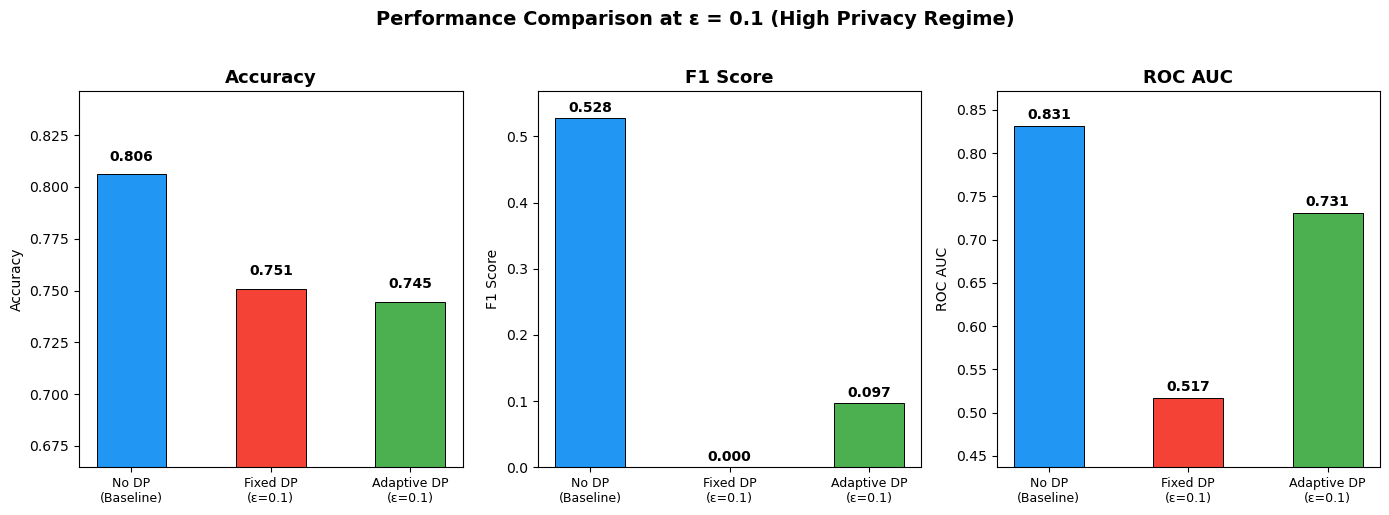

In [21]:
# Bar chart comparison at ε = 0.1
methods = [
    "No DP\n(Baseline)",
    f"Fixed DP\n(ε={EVAL_EPSILON})",
    f"Adaptive DP\n(ε={EVAL_EPSILON})"
]
metrics = {
    "Accuracy": [acc_lr,  np.mean(fixed_accs), np.mean(adap_accs)],
    "F1 Score": [f1_lr,   np.mean(fixed_f1s),  np.mean(adap_f1s)],
    "ROC AUC":  [auc_lr,  np.mean(fixed_aucs), np.mean(adap_aucs)]
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ["#2196F3", "#F44336", "#4CAF50"]

for ax, (metric_name, values) in zip(axes, metrics.items()):
    bars = ax.bar(methods, values, color=colors, width=0.5, edgecolor="black", linewidth=0.7)
    ax.set_title(metric_name, fontsize=13, fontweight="bold")
    ax.set_ylabel(metric_name)
    ymin = min(values) - 0.08
    ymax = max(values) + 0.04
    ax.set_ylim(max(0, ymin), min(1.0, ymax))
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle(f"Performance Comparison at ε = {EVAL_EPSILON} (High Privacy Regime)", 
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("comparison_single_epsilon.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
EPSILON_VALUES = [0.05, 0.1, 0.2, 0.3, 0.5, 1.0, 2.0]
N_TRIALS       = 30

sweep_results = {"epsilon": [], "Fixed_DP_AUC": [], "Adaptive_DP_AUC": [],
                 "Fixed_DP_Acc": [], "Adaptive_DP_Acc": [],
                 "Fixed_DP_F1": [],  "Adaptive_DP_F1": []}

for eps in EPSILON_VALUES:
    fixed_aucs_t, adap_aucs_t   = [], []
    fixed_accs_t, adap_accs_t   = [], []
    fixed_f1s_t,  adap_f1s_t    = [], []
    
    for trial in range(N_TRIALS):
        # Fixed DP
        X_f = add_laplace_noise_matrix(X_train_transformed,
                                       get_fixed_epsilons(eps, n_features))
        # Adaptive DP
        X_a = add_laplace_noise_matrix(X_train_transformed,
                                       get_adaptive_epsilons(eps, norm_importances))
        
        lr_f = LogisticRegression(max_iter=1000, random_state=trial).fit(X_f, y_train)
        lr_a = LogisticRegression(max_iter=1000, random_state=trial).fit(X_a, y_train)
        
        fixed_aucs_t.append(roc_auc_score(y_test, lr_f.predict_proba(X_test_transformed)[:,1]))
        adap_aucs_t.append( roc_auc_score(y_test, lr_a.predict_proba(X_test_transformed)[:,1]))
        fixed_accs_t.append(accuracy_score(y_test, lr_f.predict(X_test_transformed)))
        adap_accs_t.append( accuracy_score(y_test, lr_a.predict(X_test_transformed)))
        fixed_f1s_t.append( f1_score(y_test,       lr_f.predict(X_test_transformed)))
        adap_f1s_t.append(  f1_score(y_test,        lr_a.predict(X_test_transformed)))
    
    sweep_results["epsilon"].append(eps)
    sweep_results["Fixed_DP_AUC"].append(np.mean(fixed_aucs_t))
    sweep_results["Adaptive_DP_AUC"].append(np.mean(adap_aucs_t))
    sweep_results["Fixed_DP_Acc"].append(np.mean(fixed_accs_t))
    sweep_results["Adaptive_DP_Acc"].append(np.mean(adap_accs_t))
    sweep_results["Fixed_DP_F1"].append(np.mean(fixed_f1s_t))
    sweep_results["Adaptive_DP_F1"].append(np.mean(adap_f1s_t))
    print(f"  ε={eps:.2f} | Fixed AUC={np.mean(fixed_aucs_t):.4f} | Adaptive AUC={np.mean(adap_aucs_t):.4f} | Gap={np.mean(adap_aucs_t)-np.mean(fixed_aucs_t):+.4f}")

sweep_df = pd.DataFrame(sweep_results)
sweep_df.to_csv("privacy_utility_sweep.csv", index=False)
print("\nSweep complete. Results saved to privacy_utility_sweep.csv")
sweep_df

  ε=0.05 | Fixed AUC=0.5136 | Adaptive AUC=0.7301 | Gap=+0.2166
  ε=0.10 | Fixed AUC=0.5140 | Adaptive AUC=0.7305 | Gap=+0.2165
  ε=0.20 | Fixed AUC=0.5077 | Adaptive AUC=0.7321 | Gap=+0.2245
  ε=0.30 | Fixed AUC=0.5103 | Adaptive AUC=0.7336 | Gap=+0.2233
  ε=0.50 | Fixed AUC=0.5444 | Adaptive AUC=0.7383 | Gap=+0.1939
  ε=1.00 | Fixed AUC=0.6415 | Adaptive AUC=0.7552 | Gap=+0.1138
  ε=2.00 | Fixed AUC=0.6833 | Adaptive AUC=0.7871 | Gap=+0.1038

Sweep complete. Results saved to privacy_utility_sweep.csv


,epsilon,Fixed_DP_AUC,Adaptive_DP_AUC,Fixed_DP_Acc,Adaptive_DP_Acc,Fixed_DP_F1,Adaptive_DP_F1
0,0.05,0.513552,0.730107,0.750977,0.744765,0.0,0.096334
1,0.10,0.514025,0.730490,0.750977,0.744444,0.0,0.090544
2,0.20,0.507663,0.732123,0.750977,0.745361,0.0,0.103430
3,0.30,0.510314,0.733649,0.750977,0.746143,0.0,0.112746
4,0.50,0.544391,0.738285,0.750977,0.745063,0.0,0.138285
5,1.00,0.641487,0.755244,0.750977,0.748101,0.0,0.169124
6,2.00,0.683266,0.787074,0.750977,0.758469,0.0,0.235755


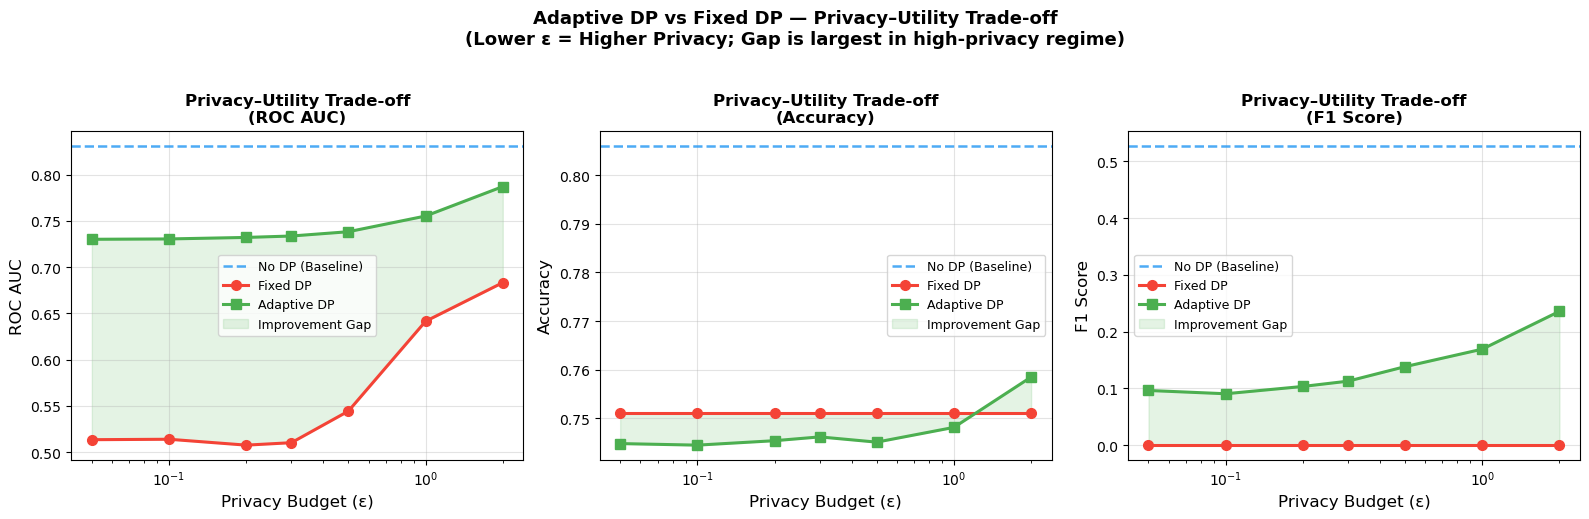

Saved: privacy_utility_tradeoff.png


In [23]:
# ── THE HEADLINE CHART ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_sweep = [
    ("ROC AUC",  "Fixed_DP_AUC",  "Adaptive_DP_AUC"),
    ("Accuracy", "Fixed_DP_Acc",  "Adaptive_DP_Acc"),
    ("F1 Score", "Fixed_DP_F1",   "Adaptive_DP_F1"),
]

for ax, (metric_name, fixed_col, adap_col) in zip(axes, metrics_sweep):
    ax.axhline(y=auc_lr if "AUC" in fixed_col else (acc_lr if "Acc" in fixed_col else f1_lr),
               color="#2196F3", linestyle="--", linewidth=1.8, label="No DP (Baseline)", alpha=0.8)
    ax.plot(sweep_df["epsilon"], sweep_df[fixed_col],
            marker="o", color="#F44336", linewidth=2.2, markersize=7, label="Fixed DP")
    ax.plot(sweep_df["epsilon"], sweep_df[adap_col],
            marker="s", color="#4CAF50", linewidth=2.2, markersize=7, label="Adaptive DP")
    
    # Shade the gap
    ax.fill_between(sweep_df["epsilon"], sweep_df[fixed_col], sweep_df[adap_col],
                    alpha=0.15, color="#4CAF50", label="Improvement Gap")
    
    ax.set_xlabel("Privacy Budget (ε)", fontsize=12)
    ax.set_ylabel(metric_name, fontsize=12)
    ax.set_title(f"Privacy–Utility Trade-off\n({metric_name})", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.35)
    ax.set_xscale("log")

plt.suptitle("Adaptive DP vs Fixed DP — Privacy–Utility Trade-off\n"
             "(Lower ε = Higher Privacy; Gap is largest in high-privacy regime)",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("privacy_utility_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: privacy_utility_tradeoff.png")

In [24]:
# Print clean summary table
print("Privacy–Utility Trade-off Summary")
print(f"{'ε':>6} | {'Fixed AUC':>10} | {'Adaptive AUC':>12} | {'AUC Gap':>8} | {'Acc Gap':>8}")
print("-" * 55)
for _, row in sweep_df.iterrows():
    gap_auc = row["Adaptive_DP_AUC"] - row["Fixed_DP_AUC"]
    gap_acc = row["Adaptive_DP_Acc"] - row["Fixed_DP_Acc"]
    print(f"{row['epsilon']:>6.2f} | {row['Fixed_DP_AUC']:>10.4f} | {row['Adaptive_DP_AUC']:>12.4f} | {gap_auc:>+8.4f} | {gap_acc:>+8.4f}")

Privacy–Utility Trade-off Summary
     ε |  Fixed AUC | Adaptive AUC |  AUC Gap |  Acc Gap
-------------------------------------------------------
  0.05 |     0.5136 |       0.7301 |  +0.2166 |  -0.0062
  0.10 |     0.5140 |       0.7305 |  +0.2165 |  -0.0065
  0.20 |     0.5077 |       0.7321 |  +0.2245 |  -0.0056
  0.30 |     0.5103 |       0.7336 |  +0.2233 |  -0.0048
  0.50 |     0.5444 |       0.7383 |  +0.1939 |  -0.0059
  1.00 |     0.6415 |       0.7552 |  +0.1138 |  -0.0029
  2.00 |     0.6833 |       0.7871 |  +0.1038 |  +0.0075


In [25]:
# Percentage degradation from baseline as ε decreases
baseline_auc = auc_lr

print("AUC Degradation from No-DP Baseline:")
print(f"{'ε':>6} | {'Fixed DP Degradation':>22} | {'Adaptive DP Degradation':>24}")
print("-" * 58)
for _, row in sweep_df.iterrows():
    deg_fixed = (baseline_auc - row["Fixed_DP_AUC"]) / baseline_auc * 100
    deg_adap  = (baseline_auc - row["Adaptive_DP_AUC"]) / baseline_auc * 100
    print(f"{row['epsilon']:>6.2f} | {deg_fixed:>20.1f}% | {deg_adap:>22.1f}%")

AUC Degradation from No-DP Baseline:
     ε |   Fixed DP Degradation |  Adaptive DP Degradation
----------------------------------------------------------
  0.05 |                 38.2% |                   12.2%
  0.10 |                 38.2% |                   12.1%
  0.20 |                 38.9% |                   11.9%
  0.30 |                 38.6% |                   11.8%
  0.50 |                 34.5% |                   11.2%
  1.00 |                 22.8% |                    9.2%
  2.00 |                 17.8% |                    5.3%


In [26]:
## ── COMPREHENSIVE RESULTS CSV ────────────────────────────────────────────────

# 1. Single-ε comparison table (ε = 0.1)
single_eps_df = pd.DataFrame({
    "Method":        ["No DP (LR Baseline)", "No DP (RF Baseline)",
                      f"Fixed DP (ε={EVAL_EPSILON})", f"Adaptive DP (ε={EVAL_EPSILON})"],
    "Accuracy":      [round(acc_lr,4),  round(acc_rf,4),
                      round(np.mean(fixed_accs),4), round(np.mean(adap_accs),4)],
    "F1_Score":      [round(f1_lr,4),   round(f1_rf,4),
                      round(np.mean(fixed_f1s),4),  round(np.mean(adap_f1s),4)],
    "ROC_AUC":       [round(auc_lr,4),  round(auc_rf,4),
                      round(np.mean(fixed_aucs),4), round(np.mean(adap_aucs),4)],
    "AUC_vs_Fixed":  ["—", "—", "—",
                      f"{np.mean(adap_aucs)-np.mean(fixed_aucs):+.4f}"],
    "Epsilon":       ["N/A","N/A", EVAL_EPSILON, EVAL_EPSILON],
    "Privacy_Type":  ["None","None","Fixed","Adaptive"]
})

# 2. Privacy-utility sweep (all ε values)
sweep_export = sweep_df.copy()
sweep_export["AUC_Gap_Adaptive_vs_Fixed"] = (
    sweep_export["Adaptive_DP_AUC"] - sweep_export["Fixed_DP_AUC"]
).round(4)
sweep_export["Acc_Gap_Adaptive_vs_Fixed"] = (
    sweep_export["Adaptive_DP_Acc"] - sweep_export["Fixed_DP_Acc"]
).round(4)
sweep_export["F1_Gap_Adaptive_vs_Fixed"] = (
    sweep_export["Adaptive_DP_F1"] - sweep_export["Fixed_DP_F1"]
).round(4)
sweep_export["Baseline_AUC"] = round(auc_lr, 4)
sweep_export["AUC_Recovery_Fixed_pct"] = (
    sweep_export["Fixed_DP_AUC"] / auc_lr * 100
).round(1)
sweep_export["AUC_Recovery_Adaptive_pct"] = (
    sweep_export["Adaptive_DP_AUC"] / auc_lr * 100
).round(1)
sweep_export = sweep_export.round(4)

# 3. Save both sheets
single_eps_df.to_csv("results_single_epsilon.csv", index=False)
sweep_export.to_csv("results_privacy_utility_sweep.csv", index=False)

# 4. Combined master CSV
master_rows = []

# Baseline rows
for _, row in single_eps_df[single_eps_df["Privacy_Type"]=="None"].iterrows():
    master_rows.append({
        "Experiment":    "Baseline",
        "Method":        row["Method"],
        "Epsilon":       "N/A",
        "Accuracy":      row["Accuracy"],
        "F1_Score":      row["F1_Score"],
        "ROC_AUC":       row["ROC_AUC"],
        "AUC_Gap_vs_Fixed": "—",
        "AUC_Recovery_%": f"{row['ROC_AUC']/auc_lr*100:.1f}%",
        "Note": "No noise — upper bound"
    })

# Sweep rows
for _, row in sweep_export.iterrows():
    master_rows.append({
        "Experiment":    "Privacy Sweep",
        "Method":        "Fixed DP",
        "Epsilon":       row["epsilon"],
        "Accuracy":      row["Fixed_DP_Acc"],
        "F1_Score":      row["Fixed_DP_F1"],
        "ROC_AUC":       row["Fixed_DP_AUC"],
        "AUC_Gap_vs_Fixed": "—",
        "AUC_Recovery_%": f"{row['AUC_Recovery_Fixed_pct']}%",
        "Note": "Equal budget per feature"
    })
    master_rows.append({
        "Experiment":    "Privacy Sweep",
        "Method":        "Adaptive DP",
        "Epsilon":       row["epsilon"],
        "Accuracy":      row["Adaptive_DP_Acc"],
        "F1_Score":      row["Adaptive_DP_F1"],
        "ROC_AUC":       row["Adaptive_DP_AUC"],
        "AUC_Gap_vs_Fixed": f"{row['AUC_Gap_Adaptive_vs_Fixed']:+}",
        "AUC_Recovery_%": f"{row['AUC_Recovery_Adaptive_pct']}%",
        "Note": "Importance-weighted budget"
    })

master_df = pd.DataFrame(master_rows)
master_df.to_csv("comparison_results.csv", index=False)

print("Saved 3 CSV files:")
print("  results_single_epsilon.csv   — single ε comparison table")
print("  results_privacy_utility_sweep.csv — full sweep with gaps & recovery %")
print("  comparison_results.csv       — master combined file")
print()
print("="*60)
print(f"FINAL RESULTS AT ε = {EVAL_EPSILON}")
print("="*60)
single_eps_df


Saved 3 CSV files:
  results_single_epsilon.csv   — single ε comparison table
  results_privacy_utility_sweep.csv — full sweep with gaps & recovery %
  comparison_results.csv       — master combined file

FINAL RESULTS AT ε = 0.1


,Method,Accuracy,F1_Score,ROC_AUC,AUC_vs_Fixed,Epsilon,Privacy_Type
0,No DP (LR Baseline),0.8062,0.5279,0.8314,—,N/A,None
1,No DP (RF Baseline),0.7767,0.5107,0.7954,—,N/A,None
2,Fixed DP (ε=0.1),0.7510,0.0000,0.5168,—,0.1,Fixed
3,Adaptive DP (ε=0.1),0.7447,0.0967,0.7307,+0.2139,0.1,Adaptive


In [27]:
fairness_df = X_test.copy()
fairness_df["true_income"]      = y_test.values
fairness_df["pred_no_dp"]       = y_pred_lr
fairness_df["pred_fixed_dp"]    = y_pred_fixed_dp
fairness_df["pred_adaptive_dp"] = y_pred_adap_dp

print("Gender distribution in test set:")
print(fairness_df["sex"].value_counts())

Gender distribution in test set:
sex
Male      4191
Female    1953
Name: count, dtype: int64


In [28]:
def compute_group_metrics(df, group_col, pred_col):
    metrics = {}
    for group in df[group_col].unique():
        subset = df[df[group_col] == group]
        tn, fp, fn, tp = confusion_matrix(
            subset["true_income"], subset[pred_col]
        ).ravel()
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fnr = fn / (tp + fn) if (tp + fn) > 0 else 0
        metrics[group] = {"Accuracy": accuracy, "TPR (Recall)": tpr, "FNR": fnr}
    return pd.DataFrame(metrics).T

fairness_no_dp    = compute_group_metrics(fairness_df, "sex", "pred_no_dp")
fairness_fixed    = compute_group_metrics(fairness_df, "sex", "pred_fixed_dp")
fairness_adaptive = compute_group_metrics(fairness_df, "sex", "pred_adaptive_dp")

fairness_all = pd.concat({
    "No DP": fairness_no_dp,
    "Fixed DP": fairness_fixed,
    "Adaptive DP": fairness_adaptive
}, axis=0)

print("Fairness Comparison (TPR by Gender):")
fairness_all

Fairness Comparison (TPR by Gender):


Accuracy  TPR (Recall)       FNR
No DP       Female  0.882232      0.062500  0.937500
            Male    0.770699      0.499234  0.500766
Fixed DP    Female  0.885305      0.000000  1.000000
            Male    0.688380      0.000000  1.000000
Adaptive DP Female  0.875576      0.035714  0.964286
            Male    0.685278      0.067381  0.932619

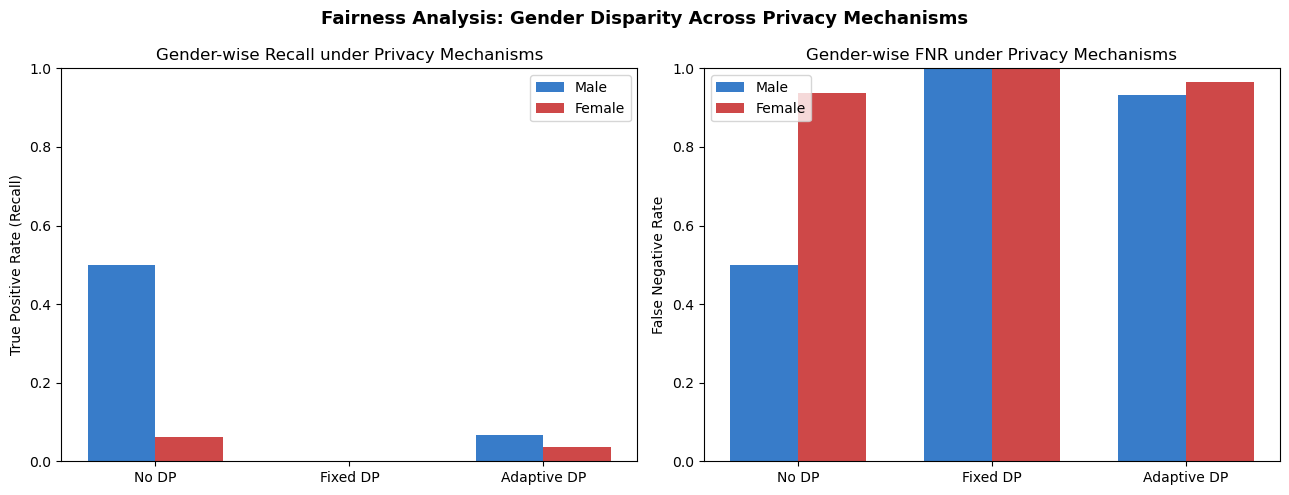

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
methods  = ["No DP", "Fixed DP", "Adaptive DP"]
x = np.arange(len(methods))
width = 0.35

# TPR chart
male_tpr   = [fairness_no_dp.loc["Male","TPR (Recall)"],
              fairness_fixed.loc["Male","TPR (Recall)"],
              fairness_adaptive.loc["Male","TPR (Recall)"]]
female_tpr = [fairness_no_dp.loc["Female","TPR (Recall)"],
              fairness_fixed.loc["Female","TPR (Recall)"],
              fairness_adaptive.loc["Female","TPR (Recall)"]]

axes[0].bar(x - width/2, male_tpr,   width, label="Male",   color="#1565C0", alpha=0.85)
axes[0].bar(x + width/2, female_tpr, width, label="Female", color="#C62828", alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(methods)
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].set_title("Gender-wise Recall under Privacy Mechanisms")
axes[0].legend(); axes[0].set_ylim(0, 1)

# FNR chart
male_fnr   = [fairness_no_dp.loc["Male","FNR"],
              fairness_fixed.loc["Male","FNR"],
              fairness_adaptive.loc["Male","FNR"]]
female_fnr = [fairness_no_dp.loc["Female","FNR"],
              fairness_fixed.loc["Female","FNR"],
              fairness_adaptive.loc["Female","FNR"]]

axes[1].bar(x - width/2, male_fnr,   width, label="Male",   color="#1565C0", alpha=0.85)
axes[1].bar(x + width/2, female_fnr, width, label="Female", color="#C62828", alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(methods)
axes[1].set_ylabel("False Negative Rate")
axes[1].set_title("Gender-wise FNR under Privacy Mechanisms")
axes[1].legend(); axes[1].set_ylim(0, 1)

plt.suptitle("Fairness Analysis: Gender Disparity Across Privacy Mechanisms",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fairness_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [30]:
# Preview the master comparison CSV
print("Master Comparison Results:")
master_df


Master Comparison Results:


,Experiment,Method,Epsilon,Accuracy,F1_Score,ROC_AUC,AUC_Gap_vs_Fixed,AUC_Recovery_%,Note
0,Baseline,No DP (LR Baseline),N/A,0.8062,0.5279,0.8314,—,100.0%,No noise — upper bound
1,Baseline,No DP (RF Baseline),N/A,0.7767,0.5107,0.7954,—,95.7%,No noise — upper bound
2,Privacy Sweep,Fixed DP,0.05,0.7510,0.0000,0.5136,—,61.8%,Equal budget per feature
3,Privacy Sweep,Adaptive DP,0.05,0.7448,0.0963,0.7301,+0.2166,87.8%,Importance-weighted budget
4,Privacy Sweep,Fixed DP,0.1,0.7510,0.0000,0.5140,—,61.8%,Equal budget per feature
5,Privacy Sweep,Adaptive DP,0.1,0.7444,0.0905,0.7305,+0.2165,87.9%,Importance-weighted budget
6,Privacy Sweep,Fixed DP,0.2,0.7510,0.0000,0.5077,—,61.1%,Equal budget per feature
7,Privacy Sweep,Adaptive DP,0.2,0.7454,0.1034,0.7321,+0.2245,88.1%,Importance-weighted budget
8,Privacy Sweep,Fixed DP,0.3,0.7510,0.0000,0.5103,—,61.4%,Equal budget per feature
9,Privacy Sweep,Adaptive DP,0.3,0.7461,0.1127,0.7336,+0.2233,88.2%,Importance-weighted budget
